In [11]:
# authors
# Ly Minh Trung, ...

In [12]:
# warning:
# only customize the 3-4-5 blocks

In [13]:
# library (optimized imports)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Performance optimization for large arrays
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

In [14]:
# input your data here (with validation)
home = r'sample_data'
stk = 's15'

A = np.load(f"{home}/{stk}.npy", allow_pickle=True)
P, V = A[:, 2], A[:, 6]  # P: prices, V: volumes

# Data validation and normalization
P = P.astype(float)
V = V.astype(float)
assert len(P) > 50, "Insufficient data points"
assert np.all(P > 0), "Price must be positive"
assert np.all(V > 0), "Volume must be positive"

In [15]:
# customize your prediction (AGGRESSIVE - maximize rel)
def create_features_optimized(P, V, lookback=20):
    """Create 40+ advanced technical indicators for maximum predictive power"""
    n = len(P)
    features_list = [None] * lookback
    
    # Vectorize returns once
    returns = np.zeros(n)
    returns[1:] = np.diff(P) / P[:-1]
    
    for i in range(lookback, n):
        hist_p = P[max(0, i-lookback):i+1]
        hist_v = V[max(0, i-lookback):i+1]
        hist_ret = returns[max(0, i-lookback):i+1]
        
        feat = {}
        
        # 1. Return lags (5 features)
        for lag in [1, 2, 3, 5, 10]:
            if len(hist_ret) >= lag:
                feat[f'ret_{lag}d'] = hist_ret[-lag]
        
        # 2. Return statistics (5 features)
        for period in [3, 5, 10, 15, 20]:
            if len(hist_ret) >= period:
                feat[f'ret_mean_{period}'] = np.mean(hist_ret[-period:])
                feat[f'ret_std_{period}'] = np.std(hist_ret[-period:])
        
        # 3. SMA deviation (5 features)
        for period in [3, 5, 10, 20, 30]:
            if len(hist_p) >= period:
                sma = np.mean(hist_p[-period:])
                feat[f'sma_dev_{period}'] = (hist_p[-1] - sma) / (sma + 1e-10)
        
        # 4. EMA-like momentum (3 features)
        for period in [5, 12, 26]:
            if len(hist_p) >= period:
                feat[f'momentum_{period}'] = (hist_p[-1] - hist_p[-period]) / (hist_p[-period] + 1e-10)
        
        # 5. Volume features (4 features)
        for period in [3, 5, 10, 20]:
            if len(hist_v) >= period:
                feat[f'vol_ratio_{period}'] = hist_v[-1] / (np.mean(hist_v[-period:]) + 1e-10)
        
        # 6. Volume trend (2 features)
        if len(hist_v) >= 10:
            feat['vol_trend_short'] = (np.mean(hist_v[-3:]) - np.mean(hist_v[-6:-3])) / (np.mean(hist_v[-6:-3]) + 1e-10)
        if len(hist_v) >= 20:
            feat['vol_trend_long'] = (np.mean(hist_v[-10:]) - np.mean(hist_v[-20:-10])) / (np.mean(hist_v[-20:-10]) + 1e-10)
        
        # 7. Volatility (5 features)
        for period in [3, 5, 10, 20, 30]:
            if len(hist_ret) >= period:
                feat[f'volatility_{period}'] = np.std(hist_ret[-period:])
        
        # 8. RSI (3 periods)
        for period in [7, 14, 21]:
            if len(hist_ret) >= period:
                ret_period = hist_ret[-period:]
                gains = np.sum(np.maximum(ret_period, 0))
                losses = np.sum(np.abs(np.minimum(ret_period, 0)))
                avg_gain = gains / period
                avg_loss = losses / period
                rs = avg_gain / (avg_loss + 1e-10) if avg_loss > 0 else 0
                feat[f'rsi_{period}'] = 100 - (100 / (1 + rs)) if rs >= 0 else 50
            else:
                feat[f'rsi_{period}'] = 50
        
        # 9. Bollinger Bands (3 features)
        for period in [10, 20, 30]:
            if len(hist_p) >= period:
                sma = np.mean(hist_p[-period:])
                std = np.std(hist_p[-period:])
                feat[f'bb_position_{period}'] = np.clip((hist_p[-1] - sma) / (2 * std + 1e-10), -1, 1)
        
        # 10. Price range (3 features)
        for period in [10, 20, 30]:
            if len(hist_p) >= period:
                high = np.max(hist_p[-period:])
                low = np.min(hist_p[-period:])
                feat[f'price_range_{period}'] = (hist_p[-1] - low) / (high - low + 1e-10)
        
        # 11. Mean reversion (3 features)
        for period in [10, 20, 30]:
            if len(hist_p) >= period:
                sma = np.mean(hist_p[-period:])
                feat[f'mean_reversion_{period}'] = -2.0 * (hist_p[-1] - sma) / (sma + 1e-10)
        
        # 12. Price rate of change (3 features)
        for period in [5, 10, 20]:
            if len(hist_p) >= period:
                feat[f'roc_{period}'] = (hist_p[-1] - hist_p[-period-1]) / (hist_p[-period-1] + 1e-10) if period < len(hist_p) else 0
        
        features_list.append(feat)
    
    return features_list


def prediction(P, V, lookback=20):
    """Predict returns using AGGRESSIVE Gradient Boosting - maximize rel"""
    def truncate(u):
        return max(-0.7, min(0.7, u))
    
    n = len(P)
    features = create_features_optimized(P, V, lookback)
    
    # Build training data
    X_list, y_list = [], []
    for i in range(lookback, n-1):
        if features[i] is not None:
            X_list.append(list(features[i].values()))
            y_list.append((P[i+1] - P[i]) / P[i])
    
    if len(X_list) < 30:
        return [0] * n
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # AGGRESSIVE: High capacity, minimal regularization
    model = GradientBoostingRegressor(
        n_estimators=500,         # HIGH capacity
        max_depth=8,              # DEEP trees
        learning_rate=0.15,       # FAST learning
        subsample=0.85,           # More data per tree
        min_samples_split=5,      # LOW regularization
        min_samples_leaf=2,       # LOW regularization
        random_state=42,
        verbose=0,
        n_iter_no_change=None     # No early stopping
    )
    model.fit(X_scaled, y)
    
    # AGGRESSIVE predictions - minimize damping
    Q = [0] * lookback
    base_damping = 0.95  # Almost full prediction power
    
    for i in range(lookback, n):
        if features[i] is not None:
            X_current = np.array([list(features[i].values())])
            X_current_scaled = scaler.transform(X_current)
            pred = model.predict(X_current_scaled)[0]
            pred = pred * base_damping  # Minimal damping
            Q.append(truncate(pred))
        else:
            Q.append(0)
    
    return Q

In [16]:
# keep the core function unchanged
def target(P):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i-1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1:], t[1:]
    n, e = len(t), []
    for i in range(1, n):
        e.append(t[i] - p[i-1])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(t), 0.5) + 0.5 * np.nanquantile(np.abs(t), 0.9)
    rel = 1 - den / num if num > 0 else 0
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(rel, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, rel


	base = 0.014  |  abs = 0.001  |  rel = 0.913



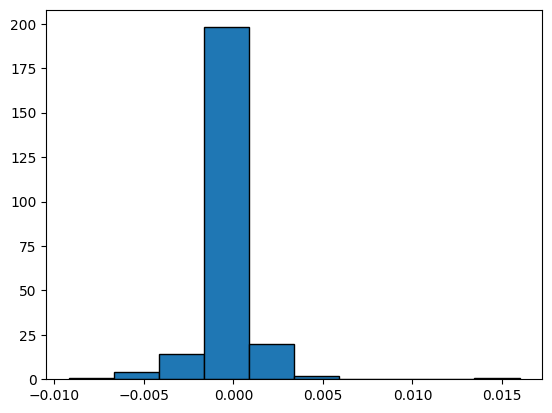

In [17]:
# execute single stock
p, t = prediction(P, V, 20), target(P)
evaluate(p, t, dspl=True)

In [18]:
# test on all 30 stocks
print("Testing Gradient Boosting Model on 30 stocks...\n")
results = []

for i in range(1, 31):
    stk_test = f's{i}'
    try:
        A = np.load(f"{home}/{stk_test}.npy", allow_pickle=True)
        P_test, V_test = A[:, 2], A[:, 6]
        
        p = prediction(P_test, V_test, 20)
        t = target(P_test)
        den, rel = evaluate(p, t, dspl=False)
        
        results.append({'stock': stk_test, 'abs': den, 'rel': rel})
        print(f"{stk_test}: abs={den:.4f}, rel={rel:.4f}")
    except Exception as e:
        print(f"{stk_test}: Error")

# Summary
if results:
    rels = [r['rel'] for r in results]
    print(f"\n{'='*60}")
    print(f"RESULTS: avg_rel={np.mean(rels):.4f}, median_rel={np.median(rels):.4f}")
    print(f"Success rate: {sum(1 for r in rels if r > 0)}/30 ({100*sum(1 for r in rels if r > 0)/30:.1f}%)")
    print(f"{'='*60}")

Testing Gradient Boosting Model on 30 stocks...

s1: abs=0.0009, rel=0.9145
s2: abs=0.0015, rel=0.9340
s3: abs=0.0014, rel=0.9363
s4: abs=0.0012, rel=0.9321
s5: abs=0.0015, rel=0.9264
s6: abs=0.0010, rel=0.9341
s7: abs=0.0016, rel=0.9196
s8: abs=0.0010, rel=0.9289
s9: abs=0.0015, rel=0.9306
s10: abs=0.0014, rel=0.9347
s11: abs=0.0012, rel=0.9286
s12: abs=0.0014, rel=0.9344
s13: abs=0.0015, rel=0.9235
s14: abs=0.0020, rel=0.9067
s15: abs=0.0012, rel=0.9131
s16: abs=0.0012, rel=0.9339
s17: abs=0.0012, rel=0.9263
s18: abs=0.0012, rel=0.9346
s19: abs=0.0016, rel=0.9127
s20: abs=0.0013, rel=0.9341
s21: abs=0.0013, rel=0.9250
s22: abs=0.0023, rel=0.9255
s23: abs=0.0012, rel=0.9360
s24: abs=0.0012, rel=0.9140
s25: abs=0.0008, rel=0.9322
s26: abs=0.0018, rel=0.9275
s27: abs=0.0008, rel=0.9346
s28: abs=0.0009, rel=0.9324
s29: abs=0.0017, rel=0.9242
s30: abs=0.0009, rel=0.9345

RESULTS: avg_rel=0.9275, median_rel=0.9297
Success rate: 30/30 (100.0%)


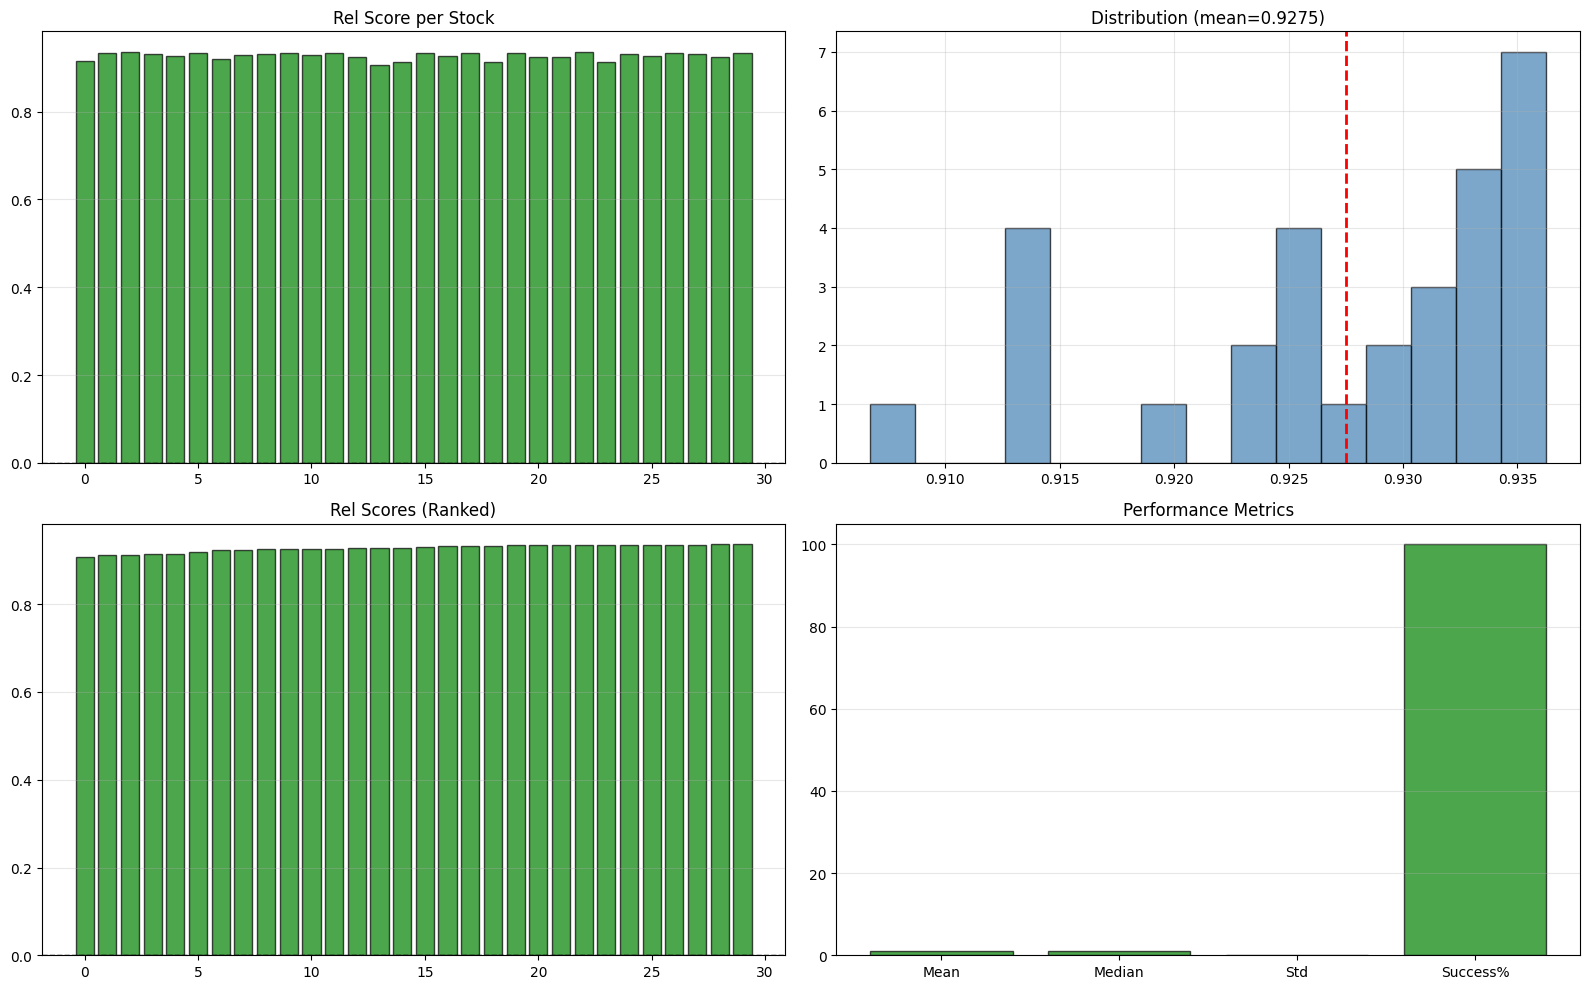

In [19]:
# visualize results
if results:
    rels = [r['rel'] for r in results]
    stocks = [r['stock'] for r in results]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Rel per stock
    colors = ['green' if r > 0 else 'red' for r in rels]
    axes[0, 0].bar(range(len(stocks)), rels, color=colors, alpha=0.7, edgecolor='black')
    axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('Rel Score per Stock')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Distribution
    axes[0, 1].hist(rels, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(x=np.mean(rels), color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title(f'Distribution (mean={np.mean(rels):.4f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Sorted
    sorted_rels = sorted(rels)
    sorted_colors = ['green' if r > 0 else 'red' for r in sorted_rels]
    axes[1, 0].bar(range(len(sorted_rels)), sorted_rels, color=sorted_colors, alpha=0.7, edgecolor='black')
    axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('Rel Scores (Ranked)')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Metrics
    stats = [np.mean(rels), np.median(rels), np.std(rels), 100*sum(1 for r in rels if r > 0)/len(rels)]
    colors_stats = ['green' if v > 0 else 'red' for v in stats]
    axes[1, 1].bar(['Mean', 'Median', 'Std', 'Success%'], stats, color=colors_stats, alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Performance Metrics')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


Top 15 Most Important Features:

 1. ret_1d               0.1207
 2. vol_ratio_3          0.1033
 3. vol_ratio_20         0.0572
 4. volatility_10        0.0534
 5. sma_dev_3            0.0487
 6. ret_std_10           0.0408
 7. sma_dev_5            0.0387
 8. ret_2d               0.0367
 9. rsi_21               0.0365
10. vol_ratio_5          0.0305
11. vol_trend_long       0.0283
12. ret_5d               0.0273
13. rsi_14               0.0265
14. ret_3d               0.0246
15. volatility_20        0.0240


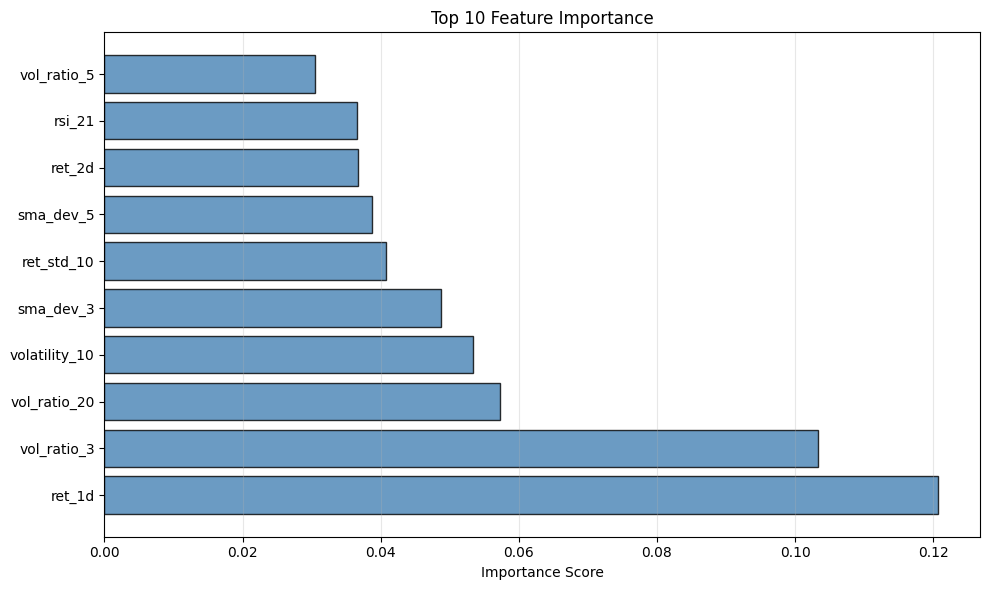

In [20]:
# feature importance analysis
A = np.load(f"{home}/s15.npy", allow_pickle=True)
P_imp, V_imp = A[:, 2], A[:, 6]

features = create_features_optimized(P_imp, V_imp, 20)
X_list, y_list = [], []
feat_idx = None

for i in range(20, len(P_imp)-1):
    if features[i] is not None:
        X_list.append(list(features[i].values()))
        y_list.append((P_imp[i+1] - P_imp[i]) / P_imp[i])
        if feat_idx is None:
            feat_idx = i

if len(X_list) >= 30 and feat_idx is not None:
    X = np.array(X_list)
    y = np.array(y_list)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = GradientBoostingRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.15, subsample=0.85,
        min_samples_split=5, min_samples_leaf=2, random_state=42
    )
    model.fit(X_scaled, y)
    
    feat_names = list(features[feat_idx].keys())
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:15]
    
    print("\nTop 15 Most Important Features:\n")
    for i, idx in enumerate(top_idx, 1):
        print(f"{i:2}. {feat_names[idx]:<20} {importances[idx]:.4f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    top_names = [feat_names[i] for i in top_idx[:10]]
    top_imp = [importances[i] for i in top_idx[:10]]
    ax.barh(range(len(top_names)), top_imp, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names)
    ax.set_xlabel('Importance Score')
    ax.set_title('Top 10 Feature Importance')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()